# **DIAGNOSIS PENYAKIT TANAMAN KEDELAI MENGGUNAKAN BAYES THEOREM**

## **Pendahuluan**

Dalam sistem berbasis pengetahuan, diagnosis penyakit dapat dilakukan dengan pendekatan probabilistik menggunakan Bayes theorem. Metode ini memungkinkan sistem untuk menghitung peluang suatu penyakit berdasarkan gejala yang diamati.

Secara matematis:

**$$P(H|E) ∝ P(H) × Π P(E_i | H)$$**

di mana:
- H adalah hipotesis penyakit
- E_i adalah gejala yang diamati

Pada kasus ini, digunakan tiga gejala utama:
1. Tanaman berumur 2–3 minggu
2. Warna daun lebih hijau dari normal
3. Daun muda keriting dan kasar

Tujuan analisis adalah menentukan penyakit dengan probabilitas tertinggi berdasarkan kombinasi gejala tersebut.

### **1. Definisi Prior Probabilitas**

In [1]:
# Prior probability penyakit
diseases = {
    "H1_Karat_Daun": 0.3,
    "H2_Busuk_Rhizoctonia": 0.9,
    "H3_Busuk_Batang": 0.9,
    "H4_Target_Spot": 0.3,
    "H5_Layu_Bakteri": 0.9,
    "H6_Kerdil": 0.7,
    "H7_Antraknosa": 0.3
}

print("=== PRIOR PROBABILITY ===")
for k, v in diseases.items():
    print(k, ":", v)

=== PRIOR PROBABILITY ===
H1_Karat_Daun : 0.3
H2_Busuk_Rhizoctonia : 0.9
H3_Busuk_Batang : 0.9
H4_Target_Spot : 0.3
H5_Layu_Bakteri : 0.9
H6_Kerdil : 0.7
H7_Antraknosa : 0.3


### **2. Definisi Likelihood (Gejala)**
Gejala yang digunakan:
* E13
* E16
* E18

In [2]:
# Likelihood dari tabel (dinormalisasi dari skala 1–9 → /10)
likelihood = {
    "H1_Karat_Daun": [3/10, 2/10, 4/10],
    "H2_Busuk_Rhizoctonia": [3/10, 0/10, 2/10],
    "H3_Busuk_Batang": [3/10, 0/10, 0/10],
    "H4_Target_Spot": [3/10, 4/10, 4/10],
    "H5_Layu_Bakteri": [9/10, 0/10, 2/10],
    "H6_Kerdil": [2/10, 9/10, 9/10],
    "H7_Antraknosa": [3/10, 0/10, 0/10]
}

print("=== LIKELIHOOD GEJALA ===")
print("Format: [E13, E16, E18]\n")
for k, v in likelihood.items():
    print(k, ":", v)

=== LIKELIHOOD GEJALA ===
Format: [E13, E16, E18]

H1_Karat_Daun : [0.3, 0.2, 0.4]
H2_Busuk_Rhizoctonia : [0.3, 0.0, 0.2]
H3_Busuk_Batang : [0.3, 0.0, 0.0]
H4_Target_Spot : [0.3, 0.4, 0.4]
H5_Layu_Bakteri : [0.9, 0.0, 0.2]
H6_Kerdil : [0.2, 0.9, 0.9]
H7_Antraknosa : [0.3, 0.0, 0.0]


### **3. Perhitungan Posterior (Unnormalized)**

In [3]:
posterior = {}

print("=== PERHITUNGAN POSTERIOR (BELUM NORMALISASI) ===\n")

for disease in diseases:
    prior = diseases[disease]
    probs = likelihood[disease]
    
    # perkalian likelihood
    likelihood_product = 1
    for p in probs:
        likelihood_product *= p
    
    posterior[disease] = prior * likelihood_product
    
    print(f"{disease}")
    print(f"Prior = {prior}")
    print(f"Likelihood product = {likelihood_product:.6f}")
    print(f"Posterior (raw) = {posterior[disease]:.6f}\n")

=== PERHITUNGAN POSTERIOR (BELUM NORMALISASI) ===

H1_Karat_Daun
Prior = 0.3
Likelihood product = 0.024000
Posterior (raw) = 0.007200

H2_Busuk_Rhizoctonia
Prior = 0.9
Likelihood product = 0.000000
Posterior (raw) = 0.000000

H3_Busuk_Batang
Prior = 0.9
Likelihood product = 0.000000
Posterior (raw) = 0.000000

H4_Target_Spot
Prior = 0.3
Likelihood product = 0.048000
Posterior (raw) = 0.014400

H5_Layu_Bakteri
Prior = 0.9
Likelihood product = 0.000000
Posterior (raw) = 0.000000

H6_Kerdil
Prior = 0.7
Likelihood product = 0.162000
Posterior (raw) = 0.113400

H7_Antraknosa
Prior = 0.3
Likelihood product = 0.000000
Posterior (raw) = 0.000000



### **4. Normalisasi Posterior**

In [4]:
total = sum(posterior.values())

posterior_normalized = {}

print("=== NORMALISASI ===\n")

for k, v in posterior.items():
    posterior_normalized[k] = v / total if total != 0 else 0
    print(f"{k} : {posterior_normalized[k]:.4f}")

=== NORMALISASI ===

H1_Karat_Daun : 0.0533
H2_Busuk_Rhizoctonia : 0.0000
H3_Busuk_Batang : 0.0000
H4_Target_Spot : 0.1067
H5_Layu_Bakteri : 0.0000
H6_Kerdil : 0.8400
H7_Antraknosa : 0.0000


### **5. Diagnosis Akhir**

In [5]:
best_disease = max(posterior_normalized, key=posterior_normalized.get)

print("=== HASIL DIAGNOSIS ===")
print("Penyakit paling mungkin:", best_disease)
print("Probabilitas:", round(posterior_normalized[best_disease], 4))

=== HASIL DIAGNOSIS ===
Penyakit paling mungkin: H6_Kerdil
Probabilitas: 0.84


### **6. Interpretasi**

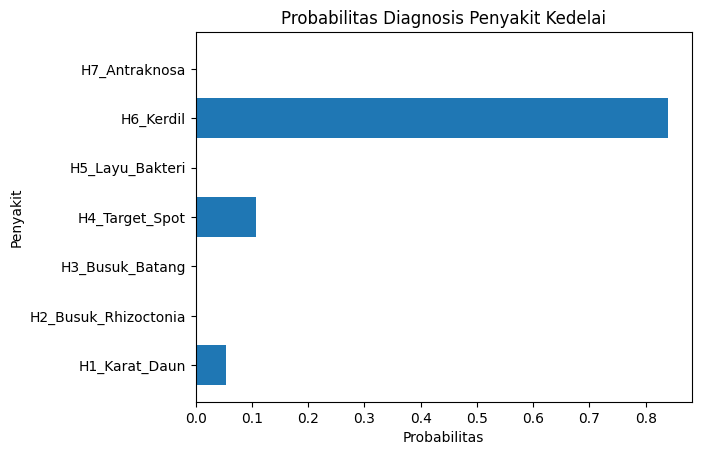

In [6]:
import matplotlib.pyplot as plt

names = list(posterior_normalized.keys())
values = list(posterior_normalized.values())

plt.figure()
plt.barh(names, values)
plt.title("Probabilitas Diagnosis Penyakit Kedelai")
plt.xlabel("Probabilitas")
plt.ylabel("Penyakit")
plt.show()